In [39]:
import pandas as pd
from scipy.stats import yeojohnson
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [26]:
# Load the data from the "Time-series Aggregated" sheet
file_path = 'A:\\UoB Msc BA\\Capstone Project\\Datasets & Notes\\Cleaned\\Cleaned.xlsx'
data = pd.read_excel(file_path, sheet_name='Time-series Aggregated')
data['Time'] = pd.to_datetime(data['Time'])

In [27]:
# Plotting function
def plot_passenger_volumes(df: pd.DataFrame, y: str, title: str) -> None:
    fig = px.line(df, x='Time', y=y, labels={'Time': 'Date'})
    fig.update_layout(template="simple_white", font=dict(size=18), title_text=title,
                      width=650, title_x=0.5, height=400)
    fig.show()


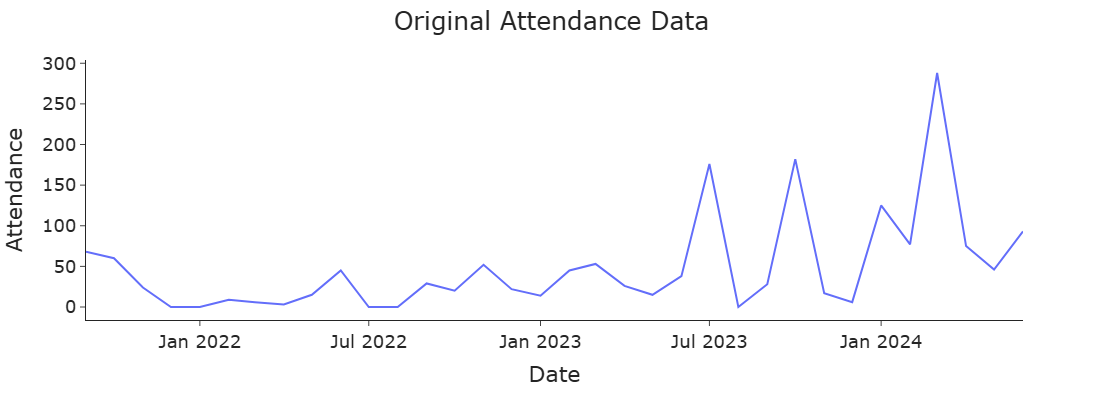

In [28]:
# Plot the original attendance data
plot_passenger_volumes(df=data, y='Attendance', title='Original Attendance Data')

In [29]:
# Decompose the time series using STL with specified period
stl = STL(data['Attendance'], seasonal=13, period=12)
result = stl.fit()
data['Trend'] = result.trend
data['Seasonal'] = result.seasonal
data['Residual'] = result.resid

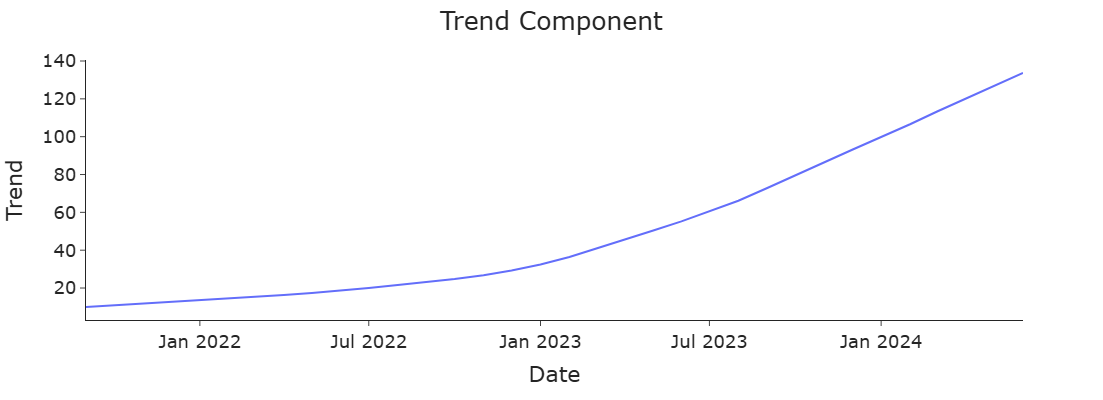

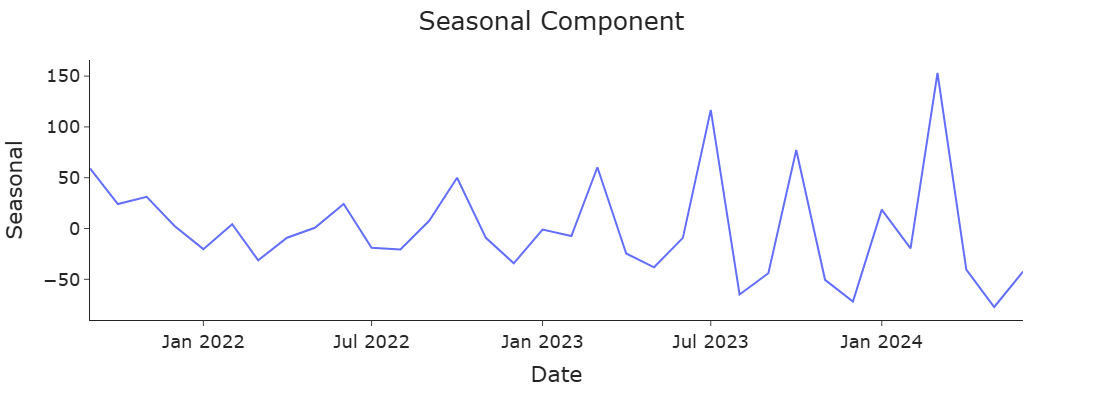

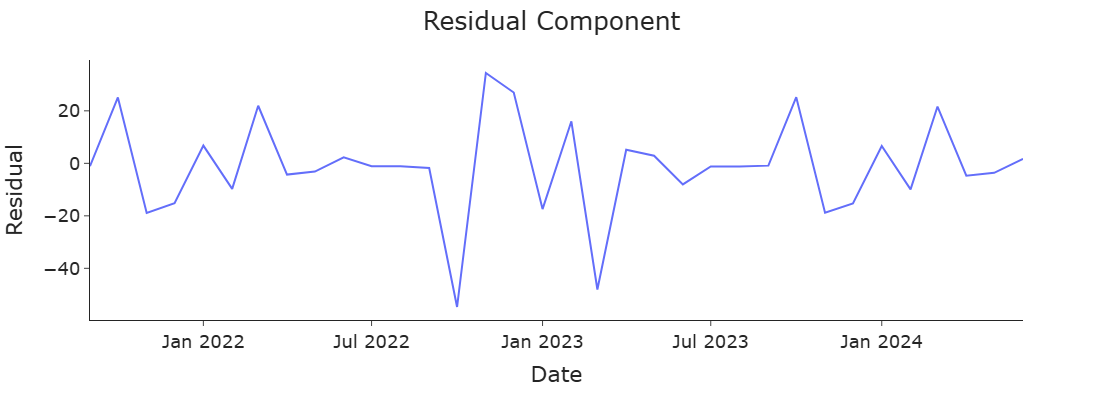

In [30]:
# Plot the decomposed components
plot_passenger_volumes(df=data, y='Trend', title='Trend Component')
plot_passenger_volumes(df=data, y='Seasonal', title='Seasonal Component')
plot_passenger_volumes(df=data, y='Residual', title='Residual Component')


In [31]:
# Make the residual component stationary using Yeo-Johnson transformation
data['Residual_YeoJohnson'], lam = yeojohnson(data['Residual'])
data["Residual_diff"] = data["Residual_YeoJohnson"].diff()
data.dropna(inplace=True)

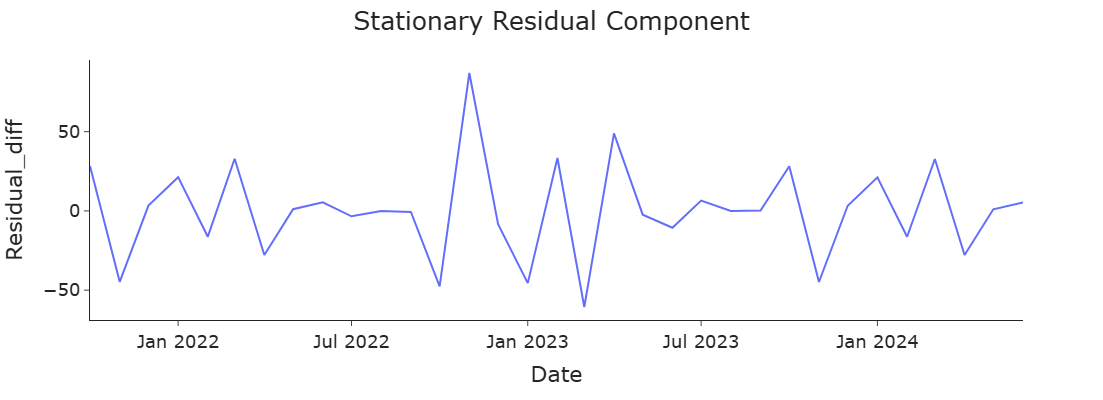

In [32]:
# Plot the stationary residual component
plot_passenger_volumes(df=data, y='Residual_diff', title='Stationary Residual Component')

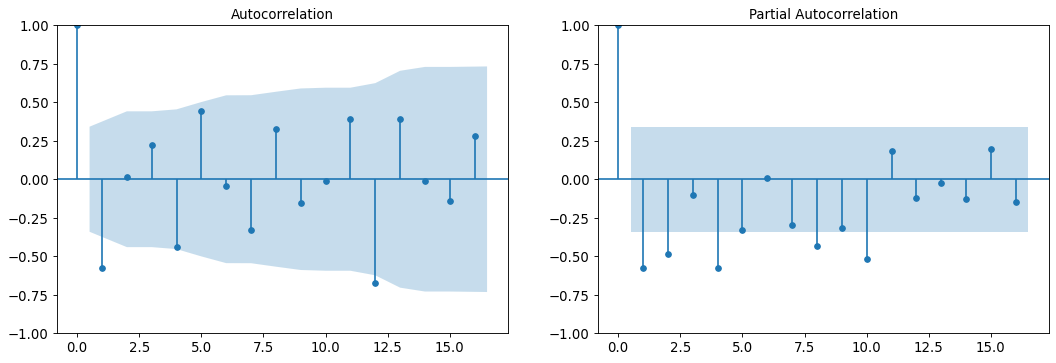

In [33]:
# Plot ACF and PACF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), dpi=80)
plot_acf(data['Residual_diff'], ax=ax1)
plot_pacf(data['Residual_diff'], ax=ax2, method='ywm')
ax1.tick_params(axis='both', labelsize=12)
ax2.tick_params(axis='both', labelsize=12)
plt.show()

In [34]:
# Split train and test for the residual component
train_residual = data.iloc[:-int(len(data) * 0.2)]
test_residual = data.iloc[-int(len(data) * 0.2):]

In [35]:
# Build ARIMA model on the residual component
model = ARIMA(train_residual['Residual_YeoJohnson'], order=(10, 1, 10), seasonal_order=(1, 1, 1, 12)).fit()
yeojohnson_forecasts = model.forecast(len(test_residual))

C:\Conda5\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Conda5\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Conda5\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Conda5\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.

C:\Conda5\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.

C:\Conda5\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum

In [36]:
# Combine forecasts with trend and seasonal components
trend_forecast = data['Trend'].iloc[-len(test_residual):].values
seasonal_forecast = data['Seasonal'].iloc[-len(test_residual):].values
final_forecasts = trend_forecast + seasonal_forecast + yeojohnson_forecasts

In [37]:
# Plot the forecasts
def plot_forecasts(forecasts: list[float], title: str) -> None:
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=train_residual['Time'], y=train_residual['Attendance'], name='Train'))
    fig.add_trace(go.Scatter(x=test_residual['Time'], y=test_residual['Attendance'], name='Test'))
    fig.add_trace(go.Scatter(x=test_residual['Time'], y=forecasts, name='Forecast'))
    fig.update_layout(template="simple_white", font=dict(size=18), title_text=title,
                      width=650, title_x=0.5, height=400, xaxis_title='Date',
                      yaxis_title='Attendance')
    fig.show()

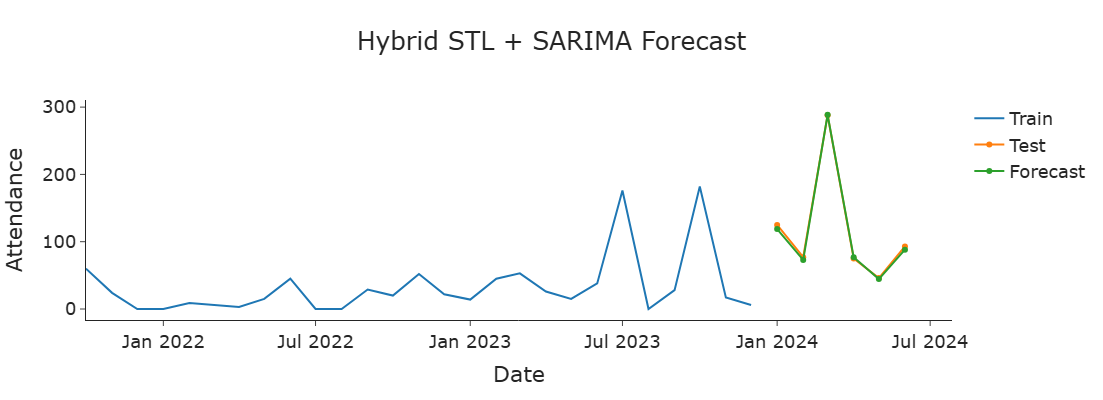

In [38]:
# Plot the final forecasts
plot_forecasts(final_forecasts, 'Hybrid STL + SARIMA Forecast')

In [40]:
# Evaluate model fit
mae = mean_absolute_error(test_residual['Attendance'], final_forecasts)
mse = mean_squared_error(test_residual['Attendance'], final_forecasts)
rmse = np.sqrt(mse)

print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')

Mean Absolute Error (MAE): 3.2114260860907997
Mean Squared Error (MSE): 14.212751910246787
Root Mean Squared Error (RMSE): 3.7699803593980152


In [41]:
# Extend the trend and seasonal components for 6 months ahead
future_trend = np.array([data['Trend'].iloc[-1]] * 10)
future_seasonal = data['Seasonal'].iloc[-12:-6].values  # Assuming seasonality repeats

In [42]:
# Forecast residuals for the next 6 months
future_residuals = model.forecast(steps=6)
future_residuals = inv_boxcox(future_residuals, lam) - 1  # Subtract 1 to revert the original transformation


C:\Conda5\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

C:\Conda5\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



In [43]:
# Combine the future components to get final forecasts
future_forecasts = future_trend + future_seasonal + future_residuals


In [44]:
# Create a DataFrame for future forecasts
future_dates = pd.date_range(start=data['Time'].iloc[-1] + pd.DateOffset(months=1), periods=6, freq='M')
future_df = pd.DataFrame({'Time': future_dates, 'Forecast': future_forecasts})

In [45]:
# Plot the forecasts
def plot_forecasts(train, test, forecasts, future_df, title: str) -> None:
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=train['Time'], y=train['Attendance'], name='Train'))
    fig.add_trace(go.Scatter(x=test['Time'], y=test['Attendance'], name='Test'))
    fig.add_trace(go.Scatter(x=test['Time'], y=forecasts, name='Forecast'))
    fig.add_trace(go.Scatter(x=future_df['Time'], y=future_df['Forecast'], name='Future Forecast'))
    fig.update_layout(template="simple_white", font=dict(size=18), title_text=title,
                      width=650, title_x=0.5, height=400, xaxis_title='Date',
                      yaxis_title='Attendance')
    fig.show()

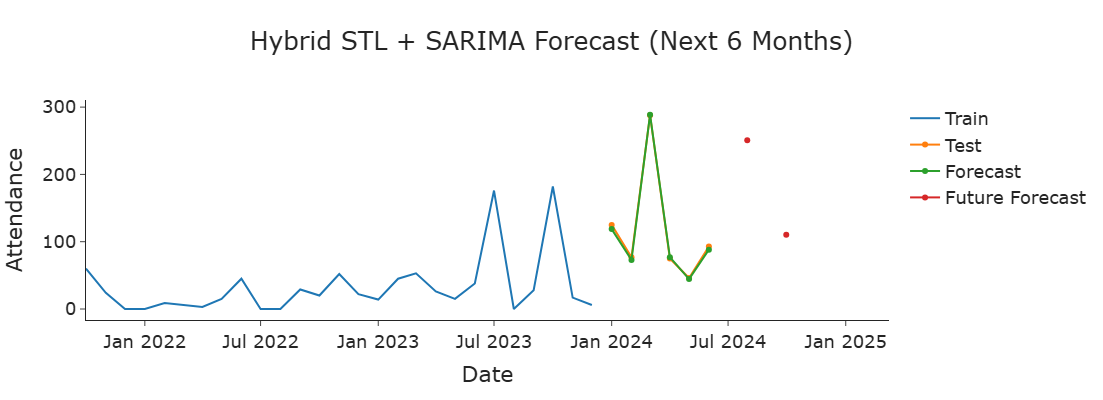

In [46]:
# Plot the final forecasts
plot_forecasts(train_residual, test_residual, final_forecasts, future_df, 'Hybrid STL + SARIMA Forecast (Next 6 Months)')

C:\Conda5\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

C:\Conda5\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



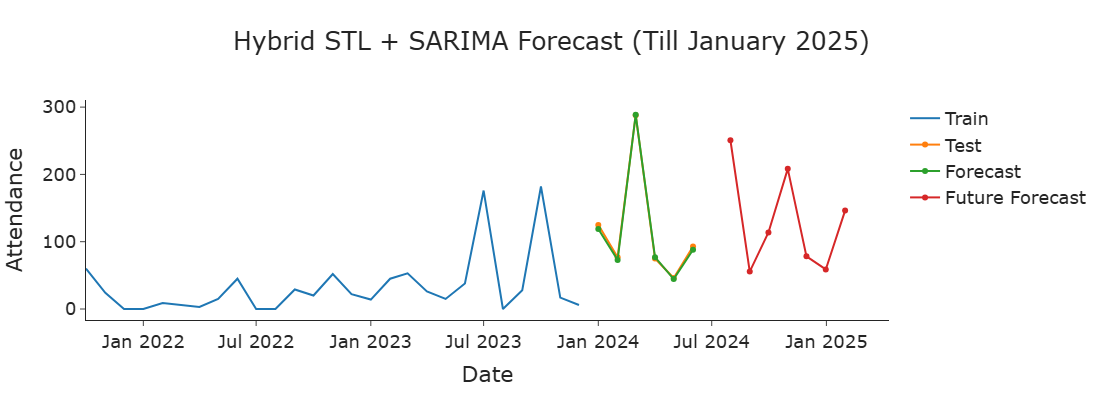

In [47]:
# Forecast until January 2025
last_date = data['Time'].max()
end_date = pd.to_datetime('2025-01-01')
months_to_forecast = (end_date.year - last_date.year) * 12 + (end_date.month - last_date.month)

# Extend the trend and seasonal components
future_trend = np.array([data['Trend'].iloc[-1]] * months_to_forecast)
seasonal_cycle_length = 12
future_seasonal = np.tile(data['Seasonal'].iloc[-seasonal_cycle_length:], int(np.ceil(months_to_forecast/seasonal_cycle_length)))[:months_to_forecast]

# Forecast residuals for the required period
future_residuals = model.forecast(steps=months_to_forecast)
future_residuals = yeojohnson(future_residuals, lam)

# Combine the future components to get final forecasts
future_forecasts = future_trend + future_seasonal + future_residuals

# Create a DataFrame for future forecasts
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=months_to_forecast, freq='M')
future_df = pd.DataFrame({'Time': future_dates, 'Forecast': future_forecasts})

# Plot the forecasts
def plot_forecasts(train, test, forecasts, future_df, title: str) -> None:
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=train['Time'], y=train['Attendance'], name='Train'))
    fig.add_trace(go.Scatter(x=test['Time'], y=test['Attendance'], name='Test'))
    fig.add_trace(go.Scatter(x=test['Time'], y=forecasts, name='Forecast'))
    fig.add_trace(go.Scatter(x=future_df['Time'], y=future_df['Forecast'], name='Future Forecast'))
    fig.update_layout(template="simple_white", font=dict(size=18), title_text=title,
                      width=650, title_x=0.5, height=400, xaxis_title='Date',
                      yaxis_title='Attendance')
    fig.show()

# Plot the final forecasts
plot_forecasts(train_residual, test_residual, final_forecasts, future_df, 'Hybrid STL + SARIMA Forecast (Till January 2025)')